In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 2070 SUPER


In [3]:
import gdown
import zipfile
import os

os.makedirs("../data", exist_ok=True)

# COD10K-v3
url = "https://drive.google.com/uc?id=1vRYAie0JcNStcSwagmCq55eirGyMYGm5"
output = "../data/COD10K.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("../data/")

print("Done")

Downloading...
From (original): https://drive.google.com/uc?id=1vRYAie0JcNStcSwagmCq55eirGyMYGm5
From (redirected): https://drive.google.com/uc?id=1vRYAie0JcNStcSwagmCq55eirGyMYGm5&confirm=t&uuid=233da23b-6b63-4809-859c-d2ea7c1e4008
To: c:\Projects\camouflage-detection\data\COD10K.zip
100%|██████████| 2.42G/2.42G [03:59<00:00, 10.1MB/s]


Done


In [8]:
# Посмотрим на имена файлов в обеих папках
img_files = sorted(os.listdir(TRAIN_IMG))[:5]
mask_files = sorted(os.listdir(TRAIN_MASK))[:5]

print("Images:", img_files)
print("Masks: ", mask_files)

Images: ['COD10K-CAM-1-Aquatic-1-BatFish-1.jpg', 'COD10K-CAM-1-Aquatic-1-BatFish-3.jpg', 'COD10K-CAM-1-Aquatic-1-BatFish-7.jpg', 'COD10K-CAM-1-Aquatic-1-BatFish-8.jpg', 'COD10K-CAM-1-Aquatic-1-BatFish-9.jpg']
Masks:  ['COD10K-CAM-1-Aquatic-1-BatFish-1.png', 'COD10K-CAM-1-Aquatic-1-BatFish-3.png', 'COD10K-CAM-1-Aquatic-1-BatFish-7.png', 'COD10K-CAM-1-Aquatic-1-BatFish-8.png', 'COD10K-CAM-1-Aquatic-1-BatFish-9.png']


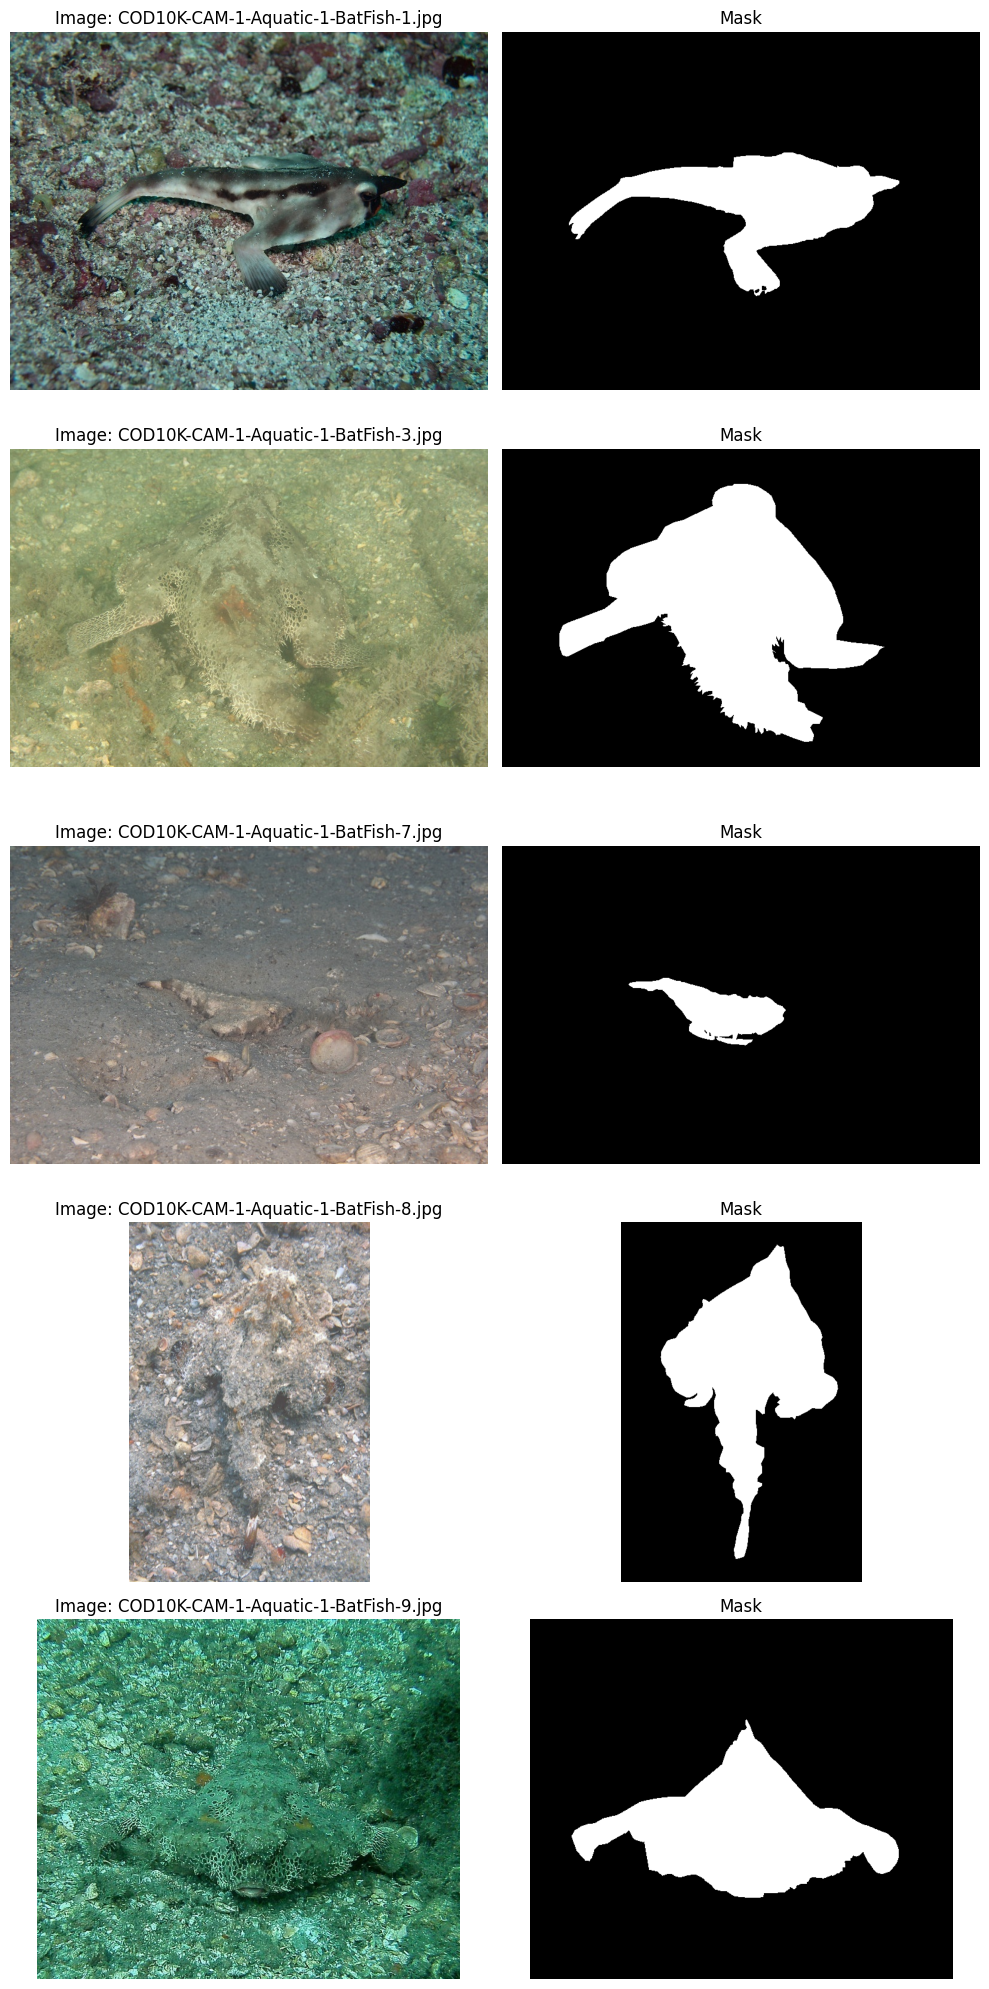

In [9]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Пути
TRAIN_IMG = "../data/COD10K-v3/Train/Image"
TRAIN_MASK = "../data/COD10K-v3/Train/GT_Object"

# Берём первые 5 файлов
images = sorted(os.listdir(TRAIN_IMG))[:5]

fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i, fname in enumerate(images):
    # Загружаем изображение
    img = cv2.imread(os.path.join(TRAIN_IMG, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Загружаем маску (то же имя файла)
    mask_name = os.path.splitext(fname)[0] + ".png"
    mask_path = os.path.join(TRAIN_MASK, mask_name)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Image: {fname}")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CODDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=352):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.images = sorted(os.listdir(img_dir))
        # ImageNet mean/std для pretrained ResNet34
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = cv2.imread(os.path.join(self.img_dir, self.images[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        
        mask_name = os.path.splitext(self.images[idx])[0] + ".png"
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        
        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        img = (img - self.mean) / self.std  # ImageNet нормализация
        mask = torch.tensor(mask).unsqueeze(0).float() / 255.0
        
        return img, mask
    
train_dataset = CODDataset(TRAIN_IMG, TRAIN_MASK)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print(f"изображений в датасете: {len(train_dataset)}")
print(f"Батчей в DataLoader: {len(train_loader)}")

In [11]:
# Берём один батч и смотрим на формы тензоров
imgs, masks = next(iter(train_loader))

print(f"Форма батча изображений: {imgs.shape}")
print(f"Форма батча масок: {masks.shape}")
print(f"Мин/макс пикселей изображения: {imgs.min():.2f} / {imgs.max():.2f}")
print(f"Мин/макс пикселей маски: {masks.min():.2f} / {masks.max():.2f}")

Форма батча изображений: torch.Size([8, 3, 352, 352])
Форма батча масок: torch.Size([8, 1, 352, 352])
Мин/макс пикселей изображения: 0.00 / 1.00
Мин/макс пикселей маски: 0.00 / 1.00


In [35]:
import segmentation_models_pytorch as smp
import torch.optim as optim
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).cuda()

criterion = smp.losses.DiceLoss(mode="binary", from_logits=True)
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [42]:
# Ячейка 2 — цикл обучения (без изменений)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for imgs, masks in train_loader:
        imgs = imgs.cuda()
        masks = masks.cuda()
        
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")

Epoch 1/10 | Loss: 0.5871
Epoch 2/10 | Loss: 0.4990
Epoch 3/10 | Loss: 0.4700
Epoch 4/10 | Loss: 0.4216
Epoch 5/10 | Loss: 0.4246
Epoch 6/10 | Loss: 0.4027
Epoch 7/10 | Loss: 0.4003
Epoch 8/10 | Loss: 0.3921
Epoch 9/10 | Loss: 0.3653
Epoch 10/10 | Loss: 0.3588


In [43]:
import os
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/unet_cod10k.pth")
print("Модель сохранена")

Модель сохранена


In [ ]:
model.load_state_dict(
    torch.load("../models/unet_cod10k.pth", map_location="cuda", weights_only=True)
)
model.eval()
print("Веса загружены")

# Проверка: убеждаемся что веса не случайные
sample_param = next(model.parameters())
print(f"Норма первого слоя: {sample_param.norm():.4f}  (должна быть > 0.1)")

In [25]:
test_dataset = CODDataset(
    "../data/COD10K-v3/Test/Image",
    "../data/COD10K-v3/Test/GT_Object"
)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Тестовых изображений: {len(test_dataset)}")

Тестовых изображений: 4000


In [ ]:
model.load_state_dict(
    torch.load("../models/unet_cod10k_normalized.pth", map_location="cuda", weights_only=True)
)
model.eval()

# Денормализация для отображения
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

imgs, masks = next(iter(test_loader))
with torch.no_grad():
    preds = model(imgs.cuda()).cpu()

preds_binary = (torch.sigmoid(preds) > 0.5).float()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    img_display = imgs[i].permute(1, 2, 0) * std + mean  # денормализация
    img_display = img_display.clamp(0, 1).numpy()

    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title("Изображение"); axes[i, 0].axis("off")

    axes[i, 1].imshow(masks[i].squeeze(), cmap="gray")
    axes[i, 1].set_title("Эталонная маска"); axes[i, 1].axis("off")

    axes[i, 2].imshow(preds_binary[i].squeeze(), cmap="gray")
    axes[i, 2].set_title("Предсказание"); axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [40]:
preds_sigmoid = torch.sigmoid(preds)
print(f"После sigmoid - мин: {preds_sigmoid.min():.4f}")
print(f"После sigmoid - макс: {preds_sigmoid.max():.4f}")
print(f"После sigmoid - среднее: {preds_sigmoid.mean():.4f}")

После sigmoid - мин: 0.0000
После sigmoid - макс: 0.1804
После sigmoid - среднее: 0.0002


## Переобучение с правильной нормализацией

Предыдущая модель обучалась без ImageNet-нормализации. Теперь датасет исправлен — нужно переобучить.

In [ ]:
import segmentation_models_pytorch as smp
import torch.optim as optim

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).cuda()

criterion = smp.losses.DiceLoss(mode="binary", from_logits=True)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for imgs, masks in train_loader:
        imgs = imgs.cuda()
        masks = masks.cuda()
        
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "../models/unet_cod10k_normalized.pth")
print("Модель сохранена → models/unet_cod10k_normalized.pth")

In [ ]:
## Оценка на тестовой выборке

model.load_state_dict(
    torch.load("../models/unet_cod10k_normalized.pth", map_location="cuda", weights_only=True)
)
model.eval()

test_dataset = CODDataset("../data/COD10K-v3/Test/Image", "../data/COD10K-v3/Test/GT_Object")
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

total_iou, total_dice = 0.0, 0.0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.cuda(), masks.cuda()
        preds = (torch.sigmoid(model(imgs)) > 0.5).float()

        inter = (preds * masks).sum(dim=(1, 2, 3))
        union = (preds + masks).clamp(0, 1).sum(dim=(1, 2, 3))
        total_iou  += (inter / (union + 1e-6)).mean().item()
        total_dice += (2 * inter / (preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) + 1e-6)).mean().item()

n = len(test_loader)
print(f"IoU:  {total_iou/n:.4f}")
print(f"Dice: {total_dice/n:.4f}")

# Визуализация первых 3 примеров
imgs_cpu, masks_cpu = next(iter(DataLoader(test_dataset, batch_size=8, shuffle=False)))
with torch.no_grad():
    preds_vis = (torch.sigmoid(model(imgs_cpu.cuda())) > 0.5).float().cpu()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    axes[i, 0].imshow(imgs_cpu[i].permute(1,2,0).numpy() * [0.229,0.224,0.225] + [0.485,0.456,0.406])
    axes[i, 0].set_title("Изображение"); axes[i, 0].axis("off")
    axes[i, 1].imshow(masks_cpu[i].squeeze(), cmap="gray")
    axes[i, 1].set_title("Эталонная маска"); axes[i, 1].axis("off")
    axes[i, 2].imshow(preds_vis[i].squeeze(), cmap="gray")
    axes[i, 2].set_title("Предсказание"); axes[i, 2].axis("off")
plt.tight_layout()
plt.show()

# Улучшения модели — шаг за шагом

Каждый шаг независимо добавляет улучшение. В конце — полный цикл обучения со всеми изменениями сразу.

## Шаг 1 — Аугментации

Камуфляж «прячется» за счёт цвета и текстуры, поэтому цветовые аугментации особенно важны.  
Используем `albumentations` — быстрее torchvision и поддерживает синхронную трансформацию маски.

In [ ]:
!pip install -q albumentations

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30,
                       border_mode=0, p=0.5),

    # Цветовые — ключевые для камуфляжа
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),

    # Blur / шум — имитация сложных условий съёмки
    A.OneOf([
        A.GaussianBlur(blur_limit=3),
        A.MotionBlur(blur_limit=3),
        A.GaussNoise(),
    ], p=0.3),

    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

print("Трансформации определены.")

In [ ]:
class CODDatasetAug(torch.utils.data.Dataset):
    """Dataset с поддержкой albumentations-трансформаций."""
    def __init__(self, img_dir, mask_dir, img_size=352, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.img_size  = img_size
        self.transform = transform
        self.images    = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(os.path.join(self.img_dir, self.images[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        mask_name = os.path.splitext(self.images[idx])[0] + ".png"
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented["image"].float()           # уже тензор после ToTensorV2
            mask = augmented["mask"].unsqueeze(0).float() / 255.0
        else:
            img  = torch.tensor(img).permute(2, 0, 1).float() / 255.0
            mask = torch.tensor(mask).unsqueeze(0).float() / 255.0

        return img, mask


# Проверим: покажем одно изображение до и после аугментации
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

raw_ds  = CODDatasetAug(TRAIN_IMG, TRAIN_MASK, transform=None)
aug_ds  = CODDatasetAug(TRAIN_IMG, TRAIN_MASK, transform=train_transform)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col in range(4):
    img_raw,  mask_raw  = raw_ds[col]
    img_aug,  mask_aug  = aug_ds[col]

    # Денормализуем аугментированное
    img_aug_display = (img_aug.permute(1, 2, 0) * std + mean).clamp(0, 1).numpy()

    axes[0, col].imshow(img_raw.permute(1, 2, 0).numpy())
    axes[0, col].set_title("Оригинал"); axes[0, col].axis("off")

    axes[1, col].imshow(img_aug_display)
    axes[1, col].set_title("После аугментации"); axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## Шаг 2 — Улучшенный лосс: Dice + Focal

Только DiceLoss плохо справляется с мелкими замаскированными объектами.  
`FocalLoss` делает акцент на сложных примерах — именно там камуфляж работает лучше всего.

In [ ]:
dice_loss  = smp.losses.DiceLoss(mode="binary", from_logits=True)
focal_loss = smp.losses.FocalLoss(mode="binary")

def combined_loss(preds, masks, alpha=0.7):
    """alpha × Dice + (1-alpha) × Focal."""
    return alpha * dice_loss(preds, masks) + (1 - alpha) * focal_loss(preds, masks)

# Быстрая проверка на случайных данных
dummy_pred  = torch.randn(4, 1, 352, 352)
dummy_mask  = (torch.rand(4, 1, 352, 352) > 0.5).float()
loss_val    = combined_loss(dummy_pred, dummy_mask)
print(f"Combined loss на случайных данных: {loss_val.item():.4f}  ✓")

## Шаг 3 — Validation split

Без валидации невозможно знать, переобучается ли модель.  
Выделяем 15% тренировочных данных как val — метрики (IoU, Dice) смотрим после каждой эпохи.

In [ ]:
from torch.utils.data import random_split

full_train = CODDatasetAug(TRAIN_IMG, TRAIN_MASK, transform=train_transform)

val_size   = int(0.15 * len(full_train))
train_size = len(full_train) - val_size
train_subset, val_subset = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# val без аугментаций — переопределяем transform для подмножества
class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img_path = os.path.join(
            self.subset.dataset.img_dir,
            self.subset.dataset.images[self.subset.indices[idx]]
        )
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (352, 352))

        mask_name = os.path.splitext(
            self.subset.dataset.images[self.subset.indices[idx]]
        )[0] + ".png"
        mask = cv2.imread(
            os.path.join(self.subset.dataset.mask_dir, mask_name),
            cv2.IMREAD_GRAYSCALE
        )
        mask = cv2.resize(mask, (352, 352))

        aug  = self.transform(image=img, mask=mask)
        return aug["image"].float(), aug["mask"].unsqueeze(0).float() / 255.0

val_dataset_clean = SubsetWithTransform(val_subset, val_transform)

train_loader_aug = torch.utils.data.DataLoader(train_subset, batch_size=8, shuffle=True,  num_workers=0)
val_loader       = torch.utils.data.DataLoader(val_dataset_clean,  batch_size=8, shuffle=False, num_workers=0)

print(f"Train: {len(train_subset)} | Val: {len(val_dataset_clean)}")


def evaluate(model, loader, device="cuda"):
    """Считает IoU и Dice на переданном DataLoader."""
    model.eval()
    total_iou, total_dice, n = 0.0, 0.0, 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = (torch.sigmoid(model(imgs)) > 0.5).float()
            inter = (preds * masks).sum(dim=(1, 2, 3))
            union = (preds + masks).clamp(0, 1).sum(dim=(1, 2, 3))
            total_iou  += (inter / (union + 1e-6)).mean().item()
            total_dice += (2 * inter / (preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) + 1e-6)).mean().item()
            n += 1
    return total_iou / n, total_dice / n

print("evaluate() готова.")

## Шаг 4 — LR Scheduler: CosineAnnealingLR

Фиксированный lr=1e-4 замедляет сходимость на поздних эпохах.  
Косинусный annealing плавно снижает lr до нуля — модель «дотачивается» без скачков.

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

# Покажем как меняется lr по эпохам (без реального обучения)
_demo_opt  = torch.optim.Adam([torch.nn.Parameter(torch.zeros(1))], lr=1e-4)
_scheduler = CosineAnnealingLR(_demo_opt, T_max=50, eta_min=1e-6)

lrs = []
for _ in range(50):
    lrs.append(_demo_opt.param_groups[0]["lr"])
    _scheduler.step()

plt.figure(figsize=(8, 3))
plt.plot(lrs)
plt.title("LR schedule: CosineAnnealingLR (T_max=50)")
plt.xlabel("Эпоха"); plt.ylabel("Learning rate")
plt.tight_layout(); plt.show()
print("Scheduler готов к использованию.")

## Шаг 5 — Mixed Precision (AMP)

Автоматическое смешанное обучение (fp16 + fp32) ускоряет тренировку на RTX 2070 Super ~1.5–2×  
и позволяет увеличить batch_size без выхода за VRAM.

In [ ]:
# AMP — новый API для torch >= 2.0
# Старый: from torch.cuda.amp import autocast, GradScaler  (deprecated)
# Новый:  torch.amp.autocast("cuda") и torch.amp.GradScaler("cuda")

scaler = torch.amp.GradScaler("cuda")

def train_step_amp(model, imgs, masks, optimizer, criterion, scaler):
    optimizer.zero_grad()
    with torch.amp.autocast("cuda"):
        preds = model(imgs)
        loss  = criterion(preds, masks)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    return loss.item()

print("AMP train_step определён (новый API).")

## Шаг 6 — Лучший энкодер: EfficientNet-B4

`resnet34` → `efficientnet-b4`: более глубокая сеть с compound scaling,  
хорошо работает на сложных задачах сегментации, при этом укладывается в 8 GB VRAM.  

> Для ещё большего прироста можно попробовать `mit_b3` (MixTransformer), но нужен `pip install timm`.

In [ ]:
# EfficientNet-B2 + UNet++ — хороший баланс качества и VRAM для RTX 2070 Super
model_v2 = smp.UnetPlusPlus(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).cuda()

total_params = sum(p.numel() for p in model_v2.parameters())
print(f"EfficientNet-B2 + UNet++: {total_params / 1e6:.1f}M параметров")

# Проверка что помещается в память
with torch.no_grad():
    _dummy = torch.randn(8, 3, 352, 352).cuda()
    _out   = model_v2(_dummy)
    print(f"VRAM после forward: {torch.cuda.memory_allocated() / 1e9:.2f} GB  — OK")
    del _dummy, _out
torch.cuda.empty_cache()

# Другие варианты (раскомментируйте нужный):
# model_v2 = smp.UnetPlusPlus(encoder_name="resnet50",        ...)  # batch=8, самый безопасный
# model_v2 = smp.UnetPlusPlus(encoder_name="efficientnet-b4", ...)  # batch=4, нужно больше VRAM

## Полное обучение со всеми улучшениями

Собираем всё вместе:
- **CODDatasetAug** с albumentations-аугментациями
- **Dice + Focal** loss
- **Train / Val** split, метрики после каждой эпохи
- **CosineAnnealingLR** scheduler
- **Mixed Precision** (AMP)
- **EfficientNet-B4 + UNet++** энкодер
- **Early stopping** по val Dice (patience=7)

In [ ]:
import os, cv2, torch
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Конфиг ──────────────────────────────────────────────────────────────
TRAIN_IMG  = "../data/COD10K-v3/Train/Image"
TRAIN_MASK = "../data/COD10K-v3/Train/GT_Object"
IMG_SIZE   = 352
BATCH_SIZE = 8       # EfficientNet-B2 + UNet++ комфортно влезает в 8GB
NUM_EPOCHS = 50
LR         = 1e-4
VAL_RATIO  = 0.15
PATIENCE   = 7
SAVE_PATH  = "../models/unet_effb2_best.pth"

# Варианты энкодера по VRAM (раскомментируйте нужный):
# ENCODER = "resnet50"        # ~25M params, batch=8 — самый безопасный вариант
ENCODER   = "efficientnet-b2" # ~9M params,  batch=8 — хороший баланс качества и памяти
# ENCODER = "efficientnet-b4" # ~19M params, batch=4 — нужно уменьшить BATCH_SIZE до 4

# ── Трансформации ────────────────────────────────────────────────────────
_train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, border_mode=0, p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.7),
    A.HueSaturationValue(p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.OneOf([A.GaussianBlur(blur_limit=3), A.MotionBlur(blur_limit=3), A.GaussNoise()], p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

_val_tf = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# ── Dataset ──────────────────────────────────────────────────────────────
class IndexedCOD(Dataset):
    def __init__(self, img_dir, mask_dir, indices, transform, img_size=IMG_SIZE):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.indices   = indices
        self.transform = transform
        self.img_size  = img_size
        self.images    = sorted(os.listdir(img_dir))

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        fname = self.images[self.indices[i]]
        img   = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, fname)), cv2.COLOR_BGR2RGB)
        img   = cv2.resize(img, (self.img_size, self.img_size))
        mask  = cv2.imread(os.path.join(self.mask_dir, os.path.splitext(fname)[0] + ".png"), cv2.IMREAD_GRAYSCALE)
        mask  = cv2.resize(mask, (self.img_size, self.img_size))
        aug   = self.transform(image=img, mask=mask)
        return aug["image"].float(), aug["mask"].unsqueeze(0).float() / 255.0

# ── Split ────────────────────────────────────────────────────────────────
all_images = sorted(os.listdir(TRAIN_IMG))
n_val = int(VAL_RATIO * len(all_images))
torch.manual_seed(42)
perm = torch.randperm(len(all_images)).tolist()
train_idx, val_idx = perm[n_val:], perm[:n_val]

train_ds = IndexedCOD(TRAIN_IMG, TRAIN_MASK, train_idx, _train_tf)
val_ds   = IndexedCOD(TRAIN_IMG, TRAIN_MASK, val_idx,   _val_tf)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

# ── Модель ───────────────────────────────────────────────────────────────
model = smp.UnetPlusPlus(
    encoder_name=ENCODER,
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).cuda()
total_params = sum(p.numel() for p in model.parameters())
print(f"Модель: UNet++ + {ENCODER} | Параметров: {total_params / 1e6:.1f}M")

# Проверка памяти — прогон одного батча
with torch.no_grad():
    _dummy = torch.randn(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE).cuda()
    _out   = model(_dummy)
    print(f"VRAM после forward pass: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    del _dummy, _out
torch.cuda.empty_cache()

# ── Лосс / оптимайзер / scheduler ───────────────────────────────────────
_dice  = smp.losses.DiceLoss(mode="binary", from_logits=True)
_focal = smp.losses.FocalLoss(mode="binary")
criterion = lambda p, m: 0.7 * _dice(p, m) + 0.3 * _focal(p, m)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler("cuda")

# ── Утилита метрик ───────────────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    iou_sum = dice_sum = n = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.cuda(), masks.cuda()
            preds = (torch.sigmoid(model(imgs)) > 0.5).float()
            inter = (preds * masks).sum(dim=(1, 2, 3))
            union = (preds + masks).clamp(0, 1).sum(dim=(1, 2, 3))
            iou_sum  += (inter / (union + 1e-6)).mean().item()
            dice_sum += (2 * inter / (preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) + 1e-6)).mean().item()
            n += 1
    return iou_sum / n, dice_sum / n

# ── Цикл обучения ────────────────────────────────────────────────────────
os.makedirs("../models", exist_ok=True)
best_dice    = 0.0
patience_cnt = 0
history      = {"train_loss": [], "val_iou": [], "val_dice": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for imgs, masks in train_dl:
        imgs, masks = imgs.cuda(), masks.cuda()
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            loss = criterion(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / len(train_dl)
    val_iou, val_dice = evaluate(model, val_dl)
    history["train_loss"].append(avg_loss)
    history["val_iou"].append(val_iou)
    history["val_dice"].append(val_dice)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
          f"Val IoU: {val_iou:.4f} | Val Dice: {val_dice:.4f} | lr: {lr_now:.2e}")

    if val_dice > best_dice:
        best_dice    = val_dice
        patience_cnt = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  -> Новый лучший Dice: {best_dice:.4f} — модель сохранена")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping на эпохе {epoch}")
            break

print(f"\nОбучение завершено. Лучший Val Dice: {best_dice:.4f}")

In [ ]:
# ── Графики истории обучения ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.set_title("Train Loss"); ax1.set_xlabel("Эпоха"); ax1.legend()

ax2.plot(history["val_iou"],  label="Val IoU")
ax2.plot(history["val_dice"], label="Val Dice")
ax2.set_title("Val Metrics"); ax2.set_xlabel("Эпоха"); ax2.legend()

plt.tight_layout(); plt.show()

In [ ]:
# ── Финальная оценка на тест-сете ────────────────────────────────────────
import matplotlib.pyplot as plt

TEST_IMG  = "../data/COD10K-v3/Test/Image"
TEST_MASK = "../data/COD10K-v3/Test/GT_Object"

model.load_state_dict(torch.load(SAVE_PATH, map_location="cuda", weights_only=True))
model.eval()

test_images = sorted(os.listdir(TEST_IMG))
test_ds = IndexedCOD(TEST_IMG, TEST_MASK, list(range(len(test_images))), _val_tf)
test_dl = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0)

iou_all, dice_all = [], []
n_empty_both = 0   # пустая маска + пустое предсказание
n_empty_mask = 0   # пустая маска в датасете

with torch.no_grad():
    for imgs, masks in test_dl:
        imgs, masks = imgs.cuda(), masks.cuda()
        preds = (torch.sigmoid(model(imgs)) > 0.5).float()

        for i in range(len(imgs)):
            p = preds[i]
            m = masks[i]
            mask_empty = m.sum() < 1

            if mask_empty:
                n_empty_mask += 1
                if p.sum() < 1:
                    n_empty_both += 1
                # Если маска пуста и предсказание тоже — это правильный ответ (Dice=1)
                # Если маска пуста, но предсказание не пусто — Dice=0 (false positive)
                dice_val = 1.0 if p.sum() < 1 else 0.0
                iou_val  = 1.0 if p.sum() < 1 else 0.0
            else:
                inter    = (p * m).sum()
                union    = (p + m).clamp(0, 1).sum()
                iou_val  = (inter / (union + 1e-6)).item()
                dice_val = (2 * inter / (p.sum() + m.sum() + 1e-6)).item()

            iou_all.append(iou_val)
            dice_all.append(dice_val)

mean_iou  = sum(iou_all)  / len(iou_all)
mean_dice = sum(dice_all) / len(dice_all)

# Только изображения С объектом (стандарт для COD-бенчмарков)
iou_obj  = [v for v, m in zip(iou_all, [masks for _, masks in test_ds]) if True]
# Пересчитаем через индексы
obj_indices = [i for i in range(len(test_ds)) if test_ds[i][1].sum() >= 1]
iou_obj  = [iou_all[i]  for i in obj_indices]
dice_obj = [dice_all[i] for i in obj_indices]

print(f"Тестовых изображений всего:       {len(test_ds)}")
print(f"  из них без объекта (пустая GT): {n_empty_mask}")
print(f"  из них с объектом:              {len(test_ds) - n_empty_mask}")
print()
print(f"── Метрики по ВСЕМ изображениям ──")
print(f"  IoU:  {mean_iou:.4f}")
print(f"  Dice: {mean_dice:.4f}")
print()
print(f"── Метрики только по изображениям С объектом (стандарт COD) ──")
print(f"  IoU:  {sum(iou_obj)/len(iou_obj):.4f}")
print(f"  Dice: {sum(dice_obj)/len(dice_obj):.4f}")

# ── Визуализация: 3 примера с объектом ──────────────────────────────────
mean_t = torch.tensor([0.485, 0.456, 0.406])
std_t  = torch.tensor([0.229, 0.224, 0.225])

# Берём примеры где маска не пустая
sample_loader = DataLoader(test_ds, batch_size=16, shuffle=True)
imgs_s, masks_s = next(iter(sample_loader))
with torch.no_grad():
    preds_s = (torch.sigmoid(model(imgs_s.cuda())) > 0.5).float().cpu()

# Фильтруем только с объектом
obj_examples = [(imgs_s[i], masks_s[i], preds_s[i])
                for i in range(len(imgs_s)) if masks_s[i].sum() >= 1][:3]

fig, axes = plt.subplots(len(obj_examples), 3, figsize=(13, 4.5 * len(obj_examples)))
for row, (img, mask, pred) in enumerate(obj_examples):
    disp = (img.permute(1,2,0) * std_t + mean_t).clamp(0,1).numpy()
    axes[row,0].imshow(disp);            axes[row,0].set_title("Изображение"); axes[row,0].axis("off")
    axes[row,1].imshow(mask.squeeze(), cmap="gray"); axes[row,1].set_title("GT маска");    axes[row,1].axis("off")
    axes[row,2].imshow(pred.squeeze(), cmap="gray"); axes[row,2].set_title("Предсказание"); axes[row,2].axis("off")
plt.tight_layout(); plt.show()